In [17]:
import os, re, requests
import numpy as np
import pandas as pd

import matplotlib as mpl

import warnings
warnings.filterwarnings("ignore")

mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

In [ ]:
#let's download and import the feature table directly from the FBMN job in GNPS2
task_id = '345d29336f5a4a70b2eeaefae56f8592'
response = requests.get(f'https://gnps2.org/result?task={task_id}&viewname=quantificationdownload&resultdisplay_type=task')
directory_path = '/.../temp'

#import the metadata
metadata = pd.read_csv('/.../metadata_all_samples.txt', sep='\t')

with open(directory_path + task_id + '.csv', 'wb') as f:
    f.write(response.content)
    print(f"File saved at {directory_path}")
    
ftable = pd.read_csv(os.path.join(directory_path + task_id + '.csv'), sep=',')
#just keep the column relative to the samples and feature ids.
ftable = ftable[[col for col in ftable.columns if col.endswith('Peak area') or col == 'row ID']]


File saved at /Users/helenarusso/Documents/Pesquisa/UCSD Post-doc/Carnitines/2025/Examples/temp


In [ ]:
#import library matches to the carnitines massQL library
library_matches = pd.read_csv('/.../library_matches_postMN_MassQL_85at5.tsv', sep='\t')

#filter first for the annotations that pass the carnitine query
library_matches = library_matches[library_matches['query_validation'] == 'carnitines']

#create another column specifically for the carnitines with putative explanation:
library_matches = library_matches[library_matches['Compound_Name'].str.contains('putative')]

library_matches['Compound_Name_simplified'] = library_matches['Compound_Name'].str.split('explanation: ').str[-1]
library_matches['Compound_Name_simplified'] = library_matches['Compound_Name_simplified'].str.replace(')', '')
library_matches['Compound_Name_simplified'] = library_matches['Compound_Name_simplified'].str.replace(', O', ';O')


In [20]:
# keep only matches to the carnitines with putative annotation
ftable_filtered = ftable[ftable['row ID'].isin(library_matches['#Scan#'].unique())]

#rename header to #Scan#
ftable_filtered = ftable_filtered.rename(columns={'row ID': '#Scan#'})

#merge annotation
ftable_filtered = pd.merge(ftable_filtered, library_matches[['#Scan#', 'Compound_Name_simplified']], 
                           on='#Scan#', how='left')

#create column scan_compound
ftable_filtered['scan_compound'] = ftable_filtered['#Scan#'].astype(str) + "_" + ftable_filtered['Compound_Name_simplified'].astype(str)

#put as first column
ftable_filtered = ftable_filtered[[ftable_filtered.columns[-1]] + list(ftable_filtered.columns[:-1])]

#drop Scan and compound_name_simplified columns
ftable_filtered = ftable_filtered.drop(columns=['#Scan#', 'Compound_Name_simplified'])

#transpose column
ftable_T = ftable_filtered.T
ftable_T.columns = ftable_T.iloc[0]   # take first row as header
ftable_T = ftable_T.drop(ftable_T.index[0]).reset_index()  # drop that row

#rename column and remove ' Peak area'
ftable_T = ftable_T.rename(columns={'index': 'filename'})
ftable_T['filename'] = ftable_T['filename'].str.replace(' Peak area', '', regex=True)


In [21]:
#merge with metadata
ftable_merged = pd.merge(ftable_T, metadata, on='filename', how='left')

#keep only samples
ftable_merged = ftable_merged[ftable_merged['sample_type'] == 'sample']

#concatenate tissue and time
ftable_merged['tissue_time'] = ftable_merged['tissue'] + "_" + ftable_merged['ZT'].astype(str)

#drop columns
ftable_merged = ftable_merged.drop(columns=['ZT', 'sample_type', 'tissue', 'filename'])

#put as first column
ftable_merged = ftable_merged[[ftable_merged.columns[-1]] + list(ftable_merged.columns[:-1])]

# use groupby to have the median of compound in each time point for each organ
ftable_merged = ftable_merged.groupby('tissue_time').median().reset_index()

#create the tissue column and time
ftable_merged['tissue'] = ftable_merged['tissue_time'].str.split('_').str[0]
ftable_merged['time'] = ftable_merged['tissue_time'].str.split('_').str[1]

#remove T from time
ftable_merged['time'] = ftable_merged['time'].str.replace('T', '', regex=True)


# Convert to ordered categorical
time_order = ['0', '4', '8', '12', '16', '20']
ftable_merged['time'] = pd.Categorical(ftable_merged['time'], categories=time_order, ordered=True)

#sort in the desired time order
ftable_merged = ftable_merged.sort_values(by=['tissue', 'time']).reset_index(drop=True)

#put as first column twice
ftable_merged = ftable_merged[[ftable_merged.columns[-1]] + list(ftable_merged.columns[:-1])]
ftable_merged = ftable_merged[[ftable_merged.columns[-1]] + list(ftable_merged.columns[:-1])]

df = ftable_merged.copy()

In [22]:
# melt the dataframe for long format
df_melted = df.melt(
    id_vars=["tissue", "time"],     # keep these fixed
    var_name="Metabolite",          # column with metabolite names
    value_name="Abundance"          # column with abundance values
)

df_melted = df_melted[df_melted['Metabolite'] != 'tissue_time']

#then finally calculate the relative abundance per combination of tissue_compound
def calculate_relative_abundance(group):
    """
    Calculate relative abundance within each tissue-metabolite group.
    Returns None for groups where all abundances are zero.
    """
    max_abundance = group['Abundance'].max()
    if max_abundance == 0:
        return None  # This group will be dropped
    else:
        group['RelAbundance'] = (group['Abundance'] / max_abundance) * 100
        return group

# Group by tissue and metabolite, then calculate relative abundance
df_melted_realabundance = df_melted.groupby(['tissue', 'Metabolite']).apply(calculate_relative_abundance).reset_index(drop=True)


In [23]:
# Create a group column for the carnitines

# Get unique metabolites
metabolites = df_melted_realabundance['Metabolite'].unique()

def categorize_metabolite(metabolite):
    """
    Categorize metabolite based on saturation (:0 vs :1,2,3...) and oxidation (;O presence)
    """
    # Extract the part after 'CAR '
    car_part = metabolite.split('CAR ')[-1]
    
    # Check for saturation level (number after colon)
    saturation_match = re.search(r':(\d+)', car_part)
    saturation = int(saturation_match.group(1)) if saturation_match else None
    
    # Check for oxidation (;O followed by optional number)
    has_oxidation = ';O' in car_part
    
    # Categorize
    if saturation == 0 and not has_oxidation:
        return "Group 1 - Saturated, No Oxidation"
    elif saturation == 0 and has_oxidation:
        return "Group 2 - Saturated, With Oxidation"
    elif saturation > 0 and not has_oxidation:
        return "Group 3 - Unsaturated, No Oxidation"
    elif saturation > 0 and has_oxidation:
        return "Group 4 - Unsaturated, With Oxidation"
    else:
        return "Unclassified"

# Create a DataFrame with metabolites and their categories
metabolite_df = pd.DataFrame({
    'Metabolite': metabolites,
    'Category': [categorize_metabolite(met) for met in metabolites]
})

# merge with the relative abundance df
df_melted_realabundance = pd.merge(df_melted_realabundance, metabolite_df, on='Metabolite', how='left')
df = df_melted_realabundance.copy()

In [24]:
# and let's also create a classification for chain length and even/odd number of carbons
df['carbons'] = df['Metabolite'].str.split(' ').str[-1]
df['carbons'] = df['carbons'].str.split(':').str[0]
df['carbons'] = df['carbons'].str.replace('C', '', regex=True)

def classify_length(c):
    if 2 <= c <= 6:
        return "short"
    elif 7 <= c <= 12:
        return "medium"
    elif 13 <= c <= 21:
        return "long"
    elif 22 <= c <= 30:
        return "very long"
    else:
        return "unknown"

# make sure carbons is numeric
df['carbons'] = df['carbons'].astype(int)

df['carbons_length'] = df['carbons'].apply(classify_length)
df['even_odd'] = df['carbons'].apply(lambda x: "even" if x % 2 == 0 else "odd")


In [25]:
df['feature'] = df['Metabolite'].str.split('_').str[0]

# make sure the Abundance column is numeric and apply log
df["Abundance"] = pd.to_numeric(df["Abundance"], errors="coerce")
df["LogAbundance"] = np.log(df["Abundance"] + 1)


In [26]:
from scipy.stats import pearsonr
from itertools import combinations

def _connected_components_from_pairs(pairs):
    """Return connected components from highly correlated metabolite pairs."""
    adjacency = {}
    for m1, m2 in pairs:
        adjacency.setdefault(m1, set()).add(m2)
        adjacency.setdefault(m2, set()).add(m1)

    visited = set()
    components = []
    for node in adjacency:
        if node in visited:
            continue
        stack = [node]
        component = set()
        while stack:
            cur = stack.pop()
            if cur in visited:
                continue
            visited.add(cur)
            component.add(cur)
            stack.extend(adjacency.get(cur, set()) - visited)
        components.append(component)
    return components

def calculate_correlation_groups(df, min_correlation=0.95, min_group_size=3, abundance_column='RelAbundance'):
    """
    Calculate correlation pairs and synchronized metabolite groups per tissue.
    Returns a table compatible with the heatmap workflow (including GROUP_SUMMARY rows).
    """
    if abundance_column not in df.columns:
        raise ValueError(f"Column '{abundance_column}' not found in dataframe.")

    records = []
    tissues = sorted(df['tissue'].dropna().unique())

    for tissue in tissues:
        tissue_data = df[df['tissue'] == tissue]
        time_matrix = tissue_data.pivot_table(
            index='time',
            columns='Metabolite',
            values=abundance_column
        ).fillna(0)

        metabolites = list(time_matrix.columns)
        if len(metabolites) < 3:
            continue

        kept_pairs = []
        for met1, met2 in combinations(metabolites, 2):
            if len(time_matrix[met1].dropna()) >= 3 and len(time_matrix[met2].dropna()) >= 3:
                corr, _ = pearsonr(time_matrix[met1], time_matrix[met2])
                if not np.isnan(corr) and abs(corr) >= min_correlation:
                    kept_pairs.append((met1, met2, corr))
                    records.append({
                        'tissue': tissue,
                        'metabolite_1': met1,
                        'metabolite_2': met2,
                        'correlation': corr,
                        'abs_correlation': abs(corr),
                        'significant': 'Yes'
                    })

        # Build metabolite groups from retained correlated pairs.
        components = _connected_components_from_pairs([(m1, m2) for m1, m2, _ in kept_pairs])
        groups = [sorted(list(c)) for c in components if len(c) >= min_group_size]

        for idx, group in enumerate(groups, start=1):
            group_id = f"{tissue}_Group_{idx}"
            records.append({
                'tissue': tissue,
                'metabolite_1': f"GROUP_SUMMARY_{group_id}",
                'metabolite_2': f"Contains {len(group)} metabolites",
                'correlation': f"Group: {'; '.join(group)}",
                'abs_correlation': len(group),
                'significant': f"Group_{idx}"
            })

    return pd.DataFrame(records)

In [27]:
# Correlation-only analysis
keep = ["StomachConts", "DuodenumConts", "JejunumConts", "IlealCont", "CecalConts", "ColonConts", "Feces", "Blood", "Urine"]

min_correlation = 0.95
min_group_size = 3
abundance_column = 'RelAbundance'

# Biofluids / GI-like set
df_biofluids = df[df['tissue'].isin(keep)].copy()
corr_biofluids = calculate_correlation_groups(
    df_biofluids,
    min_correlation=min_correlation,
    min_group_size=min_group_size,
    abundance_column=abundance_column
)

# Remaining tissues
df_tissues = df[~df['tissue'].isin(keep)].copy()
corr_tissues = calculate_correlation_groups(
    df_tissues,
    min_correlation=min_correlation,
    min_group_size=min_group_size,
    abundance_column=abundance_column
)

# Combined correlation table used by heatmap
corr_df = pd.concat([corr_biofluids, corr_tissues], ignore_index=True)

print(f"Biofluids groups: {len(corr_biofluids[corr_biofluids['metabolite_1'].str.contains('GROUP_SUMMARY', na=False)])}")
print(f"Tissues groups: {len(corr_tissues[corr_tissues['metabolite_1'].str.contains('GROUP_SUMMARY', na=False)])}")
print(f"Total combined groups: {len(corr_df[corr_df['metabolite_1'].str.contains('GROUP_SUMMARY', na=False)])}")

Biofluids groups: 27
Tissues groups: 28
Total combined groups: 55


In [28]:
#add groups information to the df. - this will be necessary for lineplots in figure 3c.

# Extract sync_groups dictionary from corr_df
sync_groups = {}

# Get group summaries from corr_df
group_summaries = corr_df[corr_df['metabolite_1'].str.contains('GROUP_SUMMARY', na=False)].copy()

for _, row in group_summaries.iterrows():
    tissue = row['tissue']
    group_id = row['significant']
    
    # Parse metabolite list from correlation column (format: "Group: met1; met2; ...")
    metabolites_str = row['correlation'].replace('Group: ', '')
    metabolites = [m.strip() for m in metabolites_str.split('; ')]
    
    # Initialize tissue in sync_groups if not present
    if tissue not in sync_groups:
        sync_groups[tissue] = {'groups': []}
    
    # Add this group to the tissue
    sync_groups[tissue]['groups'].append(metabolites)

print(f"Created sync_groups for {len(sync_groups)} tissues")
for tissue, data in sync_groups.items():
    print(f"  {tissue}: {len(data['groups'])} groups")

def add_group_column(df, sync_groups, metabolite_col='Metabolite', tissue_col='tissue'):
    """
    Add a 'Group' column to the dataframe based on sync_groups dictionary.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Your original dataframe with metabolite timecourse data
    sync_groups : dict
        Dictionary with tissue names as keys and 'groups' lists as values
    metabolite_col : str
        Name of the metabolite column in df (default: 'Metabolite')
    tissue_col : str
        Name of the tissue column in df (default: 'tissue')
    
    Returns:
    --------
    pandas.DataFrame
        DataFrame with added 'Group' column
    """
    
    # Create a copy to avoid modifying original
    df_with_groups = df.copy()
    
    # Initialize the Group column with None
    df_with_groups['Group'] = None
    
    # For each tissue in sync_groups
    for tissue, tissue_data in sync_groups.items():
        groups = tissue_data['groups']
        
        # For each group within that tissue
        for group_idx, metabolite_list in enumerate(groups, start=1):
            # Create a group name
            group_name = f"Group{group_idx}"
            
            # Find rows that match this tissue and have metabolites in this group
            mask = (df_with_groups[tissue_col] == tissue) & \
                   (df_with_groups[metabolite_col].isin(metabolite_list))
            
            # Assign the group name
            df_with_groups.loc[mask, 'Group'] = group_name
    
    # Print summary
    print("\nGroup assignment summary:")
    print(df_with_groups.groupby(['tissue', 'Group'])['Metabolite'].nunique())
    
    # Count how many rows don't have a group assigned
    unassigned = df_with_groups['Group'].isna().sum()
    if unassigned > 0:
        print(f"\nWarning: {unassigned} rows were not assigned to any group")
        print("\nTissues with unassigned metabolites:")
        unassigned_df = df_with_groups[df_with_groups['Group'].isna()]
        if not unassigned_df.empty:
            print(unassigned_df.groupby('tissue')['Metabolite'].unique())
    
    return df_with_groups


df = add_group_column(df, sync_groups)

df

Created sync_groups for 23 tissues
  Blood: 2 groups
  CecalConts: 2 groups
  ColonConts: 3 groups
  DuodenumConts: 6 groups
  Feces: 4 groups
  IlealCont: 2 groups
  JejunumConts: 2 groups
  StomachConts: 3 groups
  Urine: 3 groups
  Brain: 1 groups
  Cecum: 1 groups
  Colon: 1 groups
  Duodenum: 2 groups
  Eye: 2 groups
  Heart: 2 groups
  Ileum: 2 groups
  Jejunum: 2 groups
  Kidney: 5 groups
  Liver: 3 groups
  Lung: 2 groups
  Skin: 3 groups
  Spleen: 1 groups
  Stomach: 1 groups

Group assignment summary:
tissue         Group 
Blood          Group1    15
               Group2     3
Brain          Group1     3
CecalConts     Group1     3
               Group2     5
Cecum          Group1    20
Colon          Group1    21
ColonConts     Group1     4
               Group2     3
               Group3     6
Duodenum       Group1     4
               Group2     3
DuodenumConts  Group1    10
               Group2     3
               Group3    10
               Group4     3
             

,tissue,time,Metabolite,Abundance,RelAbundance,Category,carbons,carbons_length,even_odd,feature,LogAbundance,Group
0,Blood,0,17059_CAR C5:0,260988.6200,100.0,"Group 1 - Saturated, No Oxidation",5,short,odd,17059,12.472236,None
1,Blood,4,17059_CAR C5:0,140644.4000,53.889093,"Group 1 - Saturated, No Oxidation",5,short,odd,17059,11.853997,None
2,Blood,8,17059_CAR C5:0,116288.1000,44.55677,"Group 1 - Saturated, No Oxidation",5,short,odd,17059,11.663835,None
3,Blood,12,17059_CAR C5:0,107886.7300,41.337714,"Group 1 - Saturated, No Oxidation",5,short,odd,17059,11.588846,None
4,Blood,16,17059_CAR C5:0,157949.9800,60.519872,"Group 1 - Saturated, No Oxidation",5,short,odd,17059,11.970040,None
...,...,...,...,...,...,...,...,...,...,...,...,...
5659,Urine,4,79405_CAR C22:4,0.0000,0.0,"Group 3 - Unsaturated, No Oxidation",22,very long,even,79405,0.000000,None
5660,Urine,8,79405_CAR C22:4,0.0000,0.0,"Group 3 - Unsaturated, No Oxidation",22,very long,even,79405,0.000000,None
5661,Urine,12,79405_CAR C22:4,386.3022,72.55092,"Group 3 - Unsaturated, No Oxidation",22,very long,even,79405,5.959205,None
5662,Urine,16,79405_CAR C22:4,0.0000,0.0,"Group 3 - Unsaturated, No Oxidation",22,very long,even,79405,0.000000,None


In [ ]:
# Build and export abundance tables used by the heatmap
export_dir = '/.../correlation'
os.makedirs(export_dir, exist_ok=True)

def add_structural_columns(df_part):
    out = df_part.copy()

    # Standard token like C18:1;O2 extracted from metabolite name.
    token = out['Metabolite'].astype(str).str.split(' ').str[-1]

    if 'carbons' not in out.columns:
        out['carbons'] = token.str.extract(r'C?(\d+)', expand=False)

    if 'unsaturations' not in out.columns:
        out['unsaturations'] = token.str.extract(r':(\d+)', expand=False)

    if 'hydroxy' not in out.columns:
        hydroxy_raw = token.str.extract(r';O(\d*)', expand=False)
        out['hydroxy'] = hydroxy_raw.replace('', '1').fillna('0')

    out['carbons'] = pd.to_numeric(out['carbons'], errors='coerce')

    if 'carbons_length' not in out.columns:
        out['carbons_length'] = np.select(
            [
                out['carbons'].between(2, 6, inclusive='both'),
                out['carbons'].between(7, 12, inclusive='both'),
                out['carbons'].between(13, 21, inclusive='both'),
                out['carbons'].between(22, 30, inclusive='both')
            ],
            ['short', 'medium', 'long', 'very long'],
            default='unknown'
        )

    if 'even_odd' not in out.columns:
        out['even_odd'] = np.where(out['carbons'] % 2 == 0, 'even', 'odd')

    if 'feature' not in out.columns:
        out['feature'] = out['Metabolite'].astype(str).str.split('_').str[0]

    if 'LogAbundance' not in out.columns and 'Abundance' in out.columns:
        abundance_numeric = pd.to_numeric(out['Abundance'], errors='coerce')
        out['LogAbundance'] = np.log(abundance_numeric + 1)

    return out

abundance_df_biofluids = add_structural_columns(df_biofluids)
abundance_df_tissues = add_structural_columns(df_tissues)

export_cols = [
    'tissue', 'time', 'Metabolite', 'RelAbundance', 'Abundance', 'LogAbundance',
    'Category', 'carbons', 'carbons_length', 'even_odd', 'unsaturations', 'hydroxy', 'feature'
 ]
available_cols_biofluids = [c for c in export_cols if c in abundance_df_biofluids.columns]
available_cols_tissues = [c for c in export_cols if c in abundance_df_tissues.columns]

biofluids_path = os.path.join(export_dir, 'abundance_df_biofluids.tsv')
tissues_path = os.path.join(export_dir, 'abundance_df_tissues.tsv')

abundance_df_biofluids[available_cols_biofluids].to_csv(biofluids_path, sep='\t', index=False)
abundance_df_tissues[available_cols_tissues].to_csv(tissues_path, sep='\t', index=False)

print(f"Saved: {biofluids_path} ({abundance_df_biofluids.shape[0]} rows)")
print(f"Saved: {tissues_path} ({abundance_df_tissues.shape[0]} rows)")
print(f"Biofluids columns exported: {available_cols_biofluids}")
print(f"Tissues columns exported: {available_cols_tissues}")

Saved: /Users/helenarusso/Documents/Pesquisa/UCSD Post-doc/Carnitines/2025/Examples/Patterson_circadian_rythm/figures/all_samples_blank_sub/correlation/abundance_df_biofluids.tsv (2400 rows)
Saved: /Users/helenarusso/Documents/Pesquisa/UCSD Post-doc/Carnitines/2025/Examples/Patterson_circadian_rythm/figures/all_samples_blank_sub/correlation/abundance_df_tissues.tsv (3264 rows)
Biofluids columns exported: ['tissue', 'time', 'Metabolite', 'RelAbundance', 'Abundance', 'LogAbundance', 'Category', 'carbons', 'carbons_length', 'even_odd', 'unsaturations', 'hydroxy', 'feature']
Tissues columns exported: ['tissue', 'time', 'Metabolite', 'RelAbundance', 'Abundance', 'LogAbundance', 'Category', 'carbons', 'carbons_length', 'even_odd', 'unsaturations', 'hydroxy', 'feature']


# Heatmap - Figure 3b

In [30]:
import matplotlib as mpl

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

Total combined groups: 55
Combined abundance data shape: (5664, 13)
Unique metabolites in abundance data: 129
Total metabolites: 122
Total groups: 55
Unique unsaturation values: ['0', '1', '2', '3', '4', '5', '6']
Unique hydroxy values: ['0', '1', '2', '3']


<Figure size 1080x1656 with 0 Axes>

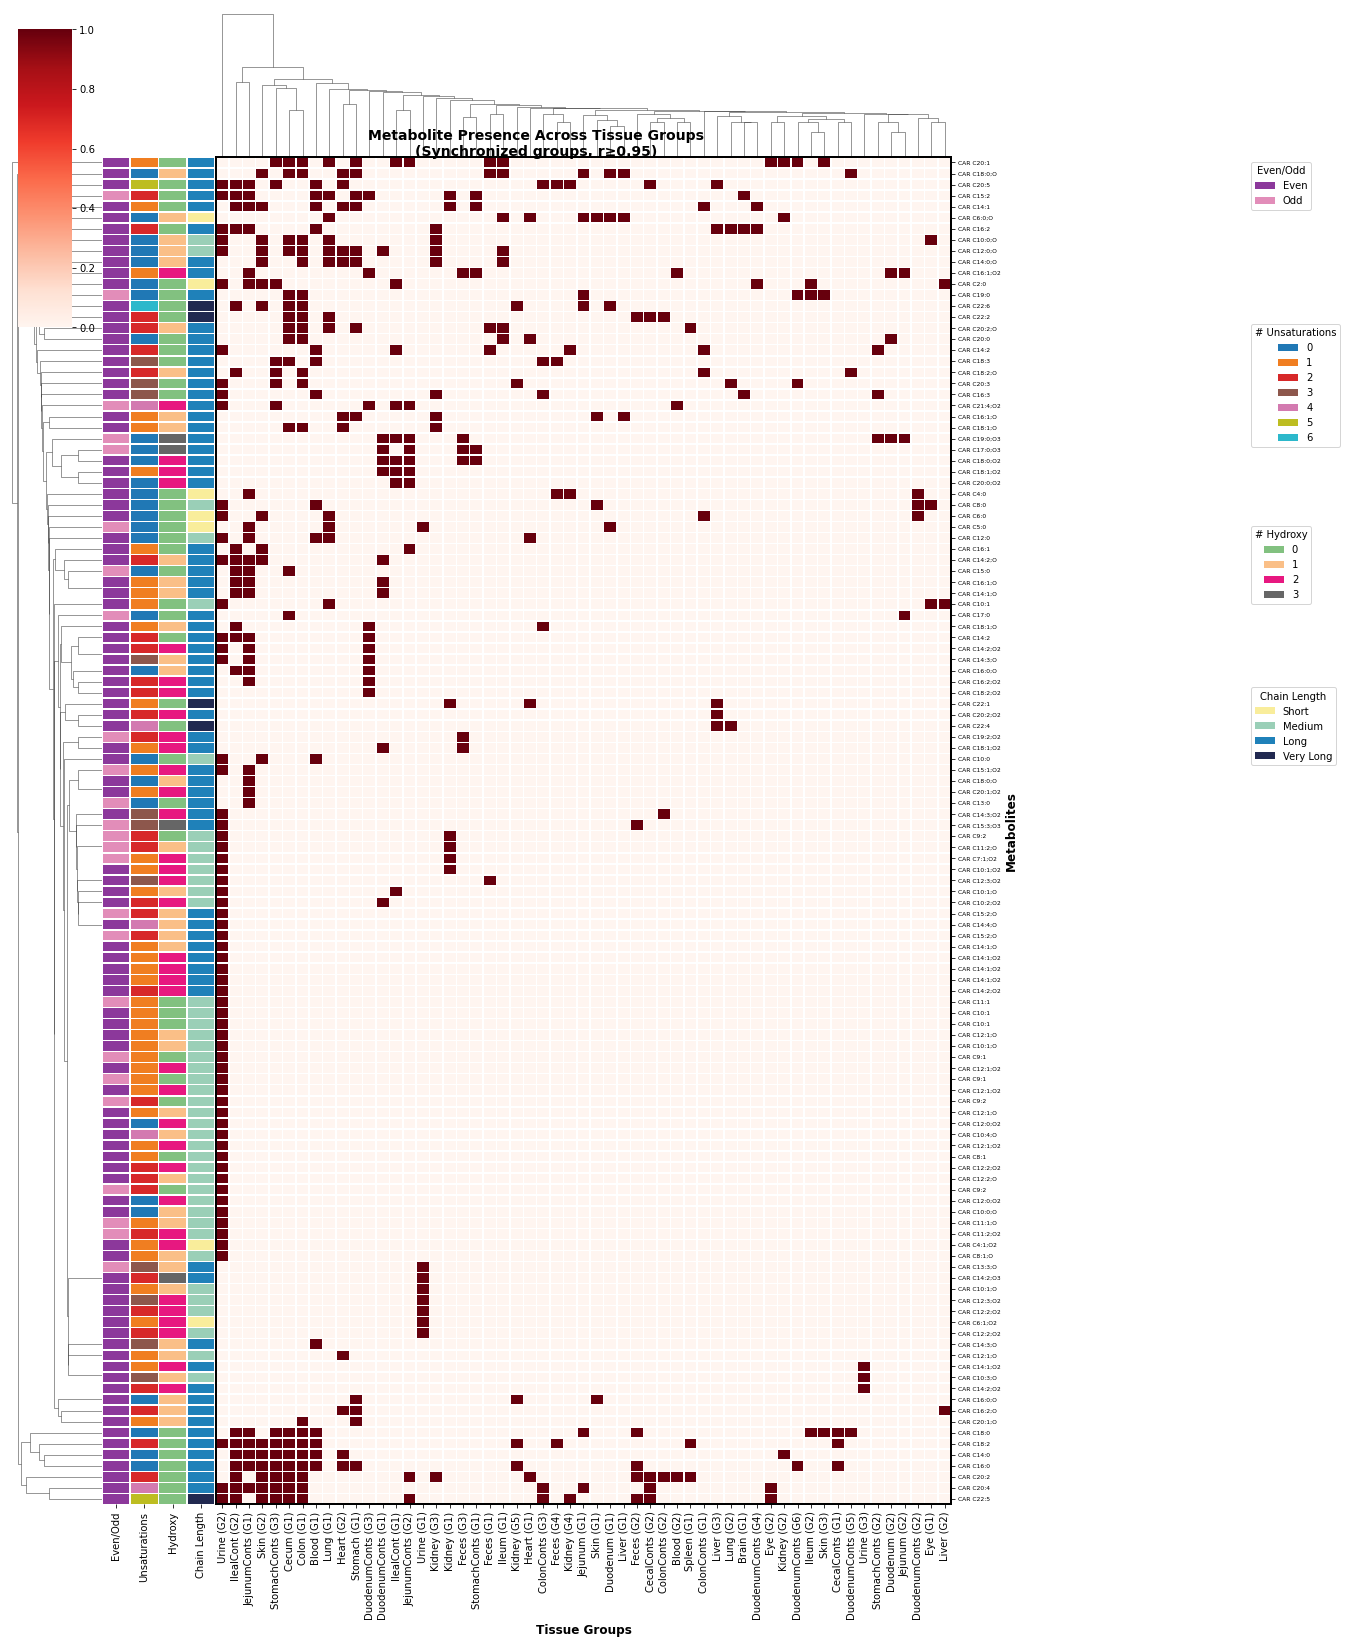

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# corr_df is created in the previous cell from in-notebook correlation calculations.
print(f"Total combined groups: {len(corr_df[corr_df['metabolite_1'].str.contains('GROUP_SUMMARY', na=False)])}")

abundance_df = pd.read_csv('/Users/helenarusso/Documents/Pesquisa/UCSD Post-doc/Carnitines/2025/Examples/Patterson_circadian_rythm/figures/all_samples_blank_sub/correlation/abundance_df_biofluids.tsv', sep='\t')

# Also load tissues abundance data
abundance_tissues = pd.read_csv('/Users/helenarusso/Documents/Pesquisa/UCSD Post-doc/Carnitines/2025/Examples/Patterson_circadian_rythm/figures/all_samples_blank_sub/correlation/abundance_df_tissues.tsv', sep='\t')

# Combine both abundance datasets
abundance_df = pd.concat([abundance_df, abundance_tissues], ignore_index=True)

print(f"Combined abundance data shape: {abundance_df.shape}")
print(f"Unique metabolites in abundance data: {abundance_df['Metabolite'].nunique()}")

# Get group summaries
group_summaries = corr_df[corr_df['metabolite_1'].str.contains('GROUP_SUMMARY', na=False)].copy()

# Create matrix: metabolites (rows) x tissue_groups (columns)
# Value = 1 if metabolite is in that group, 0 otherwise

# Collect all metabolites and groups
all_metabolites = set()
groups_list = []

for _, row in group_summaries.iterrows():
    tissue = row['tissue']
    group_id = row['significant']
    metabolites_str = row['correlation'].replace('Group: ', '')
    metabolites = [m.strip() for m in metabolites_str.split('; ')]
    
    group_name = f"{tissue}_{group_id}"
    groups_list.append({
        'group': group_name,
        'tissue': tissue,
        'metabolites': metabolites
    })
    all_metabolites.update(metabolites)

all_metabolites = sorted(list(all_metabolites))
groups_list_sorted = sorted(groups_list, key=lambda x: x['group'])

print(f"Total metabolites: {len(all_metabolites)}")
print(f"Total groups: {len(groups_list_sorted)}")

# Get all info: chain length, even_odd, unsaturations, AND hydroxy
metabolite_info = abundance_df[['Metabolite', 'carbons_length', 'even_odd', 'unsaturations', 'hydroxy']].drop_duplicates().set_index('Metabolite')

# Sort all_metabolites by chain length
chain_order = {'short': 0, 'medium': 1, 'long': 2, 'very long': 3}

metabolites_with_chain = []
for met in all_metabolites:
    if met in metabolite_info.index:
        chain = metabolite_info.loc[met, 'carbons_length']
        metabolites_with_chain.append((met, chain_order.get(chain, 999)))
    else:
        metabolites_with_chain.append((met, 999))  # Unknown at the end

# Sort by chain length order
metabolites_with_chain.sort(key=lambda x: (x[1], x[0]))  # Sort by chain order, then by name
all_metabolites_sorted = [m[0] for m in metabolites_with_chain]

# Create binary matrix with sorted metabolites
matrix = np.zeros((len(all_metabolites_sorted), len(groups_list_sorted)))

for j, group_info in enumerate(groups_list_sorted):
    for met in group_info['metabolites']:
        if met in all_metabolites_sorted:
            i = all_metabolites_sorted.index(met)
            matrix[i, j] = 1

# Create DataFrame for heatmap with sorted metabolites
heatmap_df = pd.DataFrame(
    matrix,
    index=all_metabolites_sorted,
    columns=[g['group'] for g in groups_list_sorted]
)

# Define custom color schemes
carbons_length_colors = {
    'short': '#F9ED9B',
    'medium': '#9ACFB7', 
    'long': '#1F81B9',
    'very long': '#212950'
}

even_odd_colors = {
    'even': '#8C389B',
    'odd':  '#E28DB9'
}

unsaturations_colors = {
   '0': '#2078B5',
   '1': '#F07E21', 
   '2': '#D72829',
   '3': '#8D574C',
   '4': '#D37AB0',
   '5': '#BDBD21', 
   '6': '#2CB8CB'
}

hydroxy_colors = {
    '0': '#82C180',
    '1': '#FABF87', 
    '2': '#E71880',
    '3': '#666666'
}

# Get unique values for dynamic legend creation
unsaturation_values = []
hydroxy_values = []
for met in all_metabolites_sorted:
    if met in metabolite_info.index:
        unsat = str(metabolite_info.loc[met, 'unsaturations'])
        hydrox = str(metabolite_info.loc[met, 'hydroxy'])
        unsaturation_values.append(unsat)
        hydroxy_values.append(hydrox)
    else:
        unsaturation_values.append('NA')
        hydroxy_values.append('NA')

unique_unsaturations = sorted(set(unsaturation_values) - {'NA'})
unique_hydroxy = sorted(set(hydroxy_values) - {'NA'})
print(f"Unique unsaturation values: {unique_unsaturations}")
print(f"Unique hydroxy values: {unique_hydroxy}")

# Create four separate color lists
chain_color_list = []
even_odd_color_list = []
unsaturation_color_list = []
hydroxy_color_list = []

for met in all_metabolites_sorted:
    if met in metabolite_info.index:
        chain = metabolite_info.loc[met, 'carbons_length']
        even_odd = metabolite_info.loc[met, 'even_odd']
        unsaturations = str(metabolite_info.loc[met, 'unsaturations'])
        hydroxy = str(metabolite_info.loc[met, 'hydroxy'])

        chain_color_list.append(carbons_length_colors.get(chain, '#CCCCCC'))
        even_odd_color_list.append(even_odd_colors.get(even_odd, '#CCCCCC'))
        unsaturation_color_list.append(unsaturations_colors.get(unsaturations, '#CCCCCC'))
        hydroxy_color_list.append(hydroxy_colors.get(hydroxy, '#CCCCCC'))
    else:
        chain_color_list.append('#CCCCCC')
        even_odd_color_list.append('#CCCCCC')
        unsaturation_color_list.append('#CCCCCC')
        hydroxy_color_list.append('#CCCCCC')

# Combine all four color lists into a DataFrame for row_colors
# NEW ORDER: Even/Odd, Unsaturations, Hydroxy, Chain Length
row_colors_df = pd.DataFrame({
    'Even/Odd': even_odd_color_list,
    'Unsaturations': unsaturation_color_list,
    'Hydroxy': hydroxy_color_list,
    'Chain Length': chain_color_list
}, index=all_metabolites_sorted)

# Create the clustered heatmap with all four color columns
fig = plt.figure(figsize=(15, 23))

g = sns.clustermap(
    heatmap_df,
    cmap='Reds',
    # cbar=False,  # Remove the colorbar
    row_colors=row_colors_df,
    col_cluster=True,
    row_cluster=True,
    linewidths=0.5,
    figsize=(15, 23),
    yticklabels=True,
    xticklabels=True,
    dendrogram_ratio=0.1
)

# Add black border around heatmap using spines
for spine in g.ax_heatmap.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor('black')
    spine.set_linewidth(2)

g.ax_heatmap.set_xlabel('Tissue Groups', fontsize=12, fontweight='bold')
g.ax_heatmap.set_ylabel('Metabolites', fontsize=12, fontweight='bold')

# Format Y-axis labels (metabolites) - keep only text after underscore
formatted_yticklabels = []
for label in g.ax_heatmap.get_yticklabels():
    text = label.get_text()
    # Split by underscore and keep only the second part (after _)
    if '_' in text:
        formatted_text = text.split('_', 1)[1]  # Split only on first underscore, keep second part
    else:
        formatted_text = text
    formatted_yticklabels.append(formatted_text)

g.ax_heatmap.set_yticklabels(formatted_yticklabels, fontsize=6)

# Format X-axis labels (tissue groups) - convert "Tissue_Group_X" to "Tissue (GX)"
formatted_xticklabels = []
for label in g.ax_heatmap.get_xticklabels():
    text = label.get_text()
    # Split by underscore
    parts = text.split('_')
    if len(parts) >= 3 and parts[1] == 'Group':
        # Format as "Tissue (GX)"
        formatted_text = f"{parts[0]} (G{parts[2]})"
    else:
        formatted_text = text
    formatted_xticklabels.append(formatted_text)

g.ax_heatmap.set_xticklabels(formatted_xticklabels, rotation=90, ha='center')

plt.suptitle('Metabolite Presence Across Tissue Groups\n(Synchronized groups, r≥0.95)', 
             fontsize=14, fontweight='bold', y=0.92)

# Add legend for chain length
from matplotlib.patches import Patch
chain_legend_elements = [
    Patch(facecolor=carbons_length_colors['short'], label='Short'),
    Patch(facecolor=carbons_length_colors['medium'], label='Medium'),
    Patch(facecolor=carbons_length_colors['long'], label='Long'),
    Patch(facecolor=carbons_length_colors['very long'], label='Very Long')
]

# Add legend for even/odd
even_odd_legend_elements = [
    Patch(facecolor=even_odd_colors['even'], label='Even'),
    Patch(facecolor=even_odd_colors['odd'], label='Odd')
]

# Add legend for unsaturations - only include values present in data
unsaturation_legend_elements = [
    Patch(facecolor=unsaturations_colors[val], label=val) 
    for val in unique_unsaturations if val in unsaturations_colors
]

# Add legend for hydroxy - only include values present in data
hydroxy_legend_elements = [
    Patch(facecolor=hydroxy_colors[val], label=val) 
    for val in unique_hydroxy if val in hydroxy_colors
]

# Place legends (reordered to match new column order)
legend1 = g.ax_heatmap.legend(handles=even_odd_legend_elements, title='Even/Odd',
                              bbox_to_anchor=(1.4, 1), loc='upper left', frameon=True)
g.ax_heatmap.add_artist(legend1)  # Add first legend back

legend2 = g.ax_heatmap.legend(handles=unsaturation_legend_elements, title='# Unsaturations',
                              bbox_to_anchor=(1.4, 0.88), loc='upper left', frameon=True)
g.ax_heatmap.add_artist(legend2)  # Add second legend back

legend3 = g.ax_heatmap.legend(handles=hydroxy_legend_elements, title='# Hydroxy',
                              bbox_to_anchor=(1.4, 0.73), loc='upper left', frameon=True)
g.ax_heatmap.add_artist(legend3)  # Add third legend back

legend4 = g.ax_heatmap.legend(handles=chain_legend_elements, title='Chain Length',
                              bbox_to_anchor=(1.4, 0.61), loc='upper left', frameon=True)

# plt.savefig('/.../metabolite_group_heatmap.pdf')
plt.show()

# Heatmap - Figure 3c

In [32]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.lines import Line2D
from scipy.interpolate import make_interp_spline
from scipy.stats import t


def plot_timecourses_by_tissue(
    df,
    y_col="Abundance",
    time_col="time",
    metabolite_col="Metabolite",
    tissue_col="tissue",
    # filters
    metabolites=None,             # list[str] or None
    tissues=None,                 # list[str] or None (order respected)
    feature_group=None,           # str or None - filter by this group value (e.g., "Group1", "Group2")
    # central tendency & CI
    center="mean",                # "mean" or "median"
    show_ci=True,
    ci=95,                        # e.g., 95
    ci_method="t",                # "t" or "bootstrap"
    n_boot=1000,                  # used when ci_method="bootstrap"
    # rendering
    smooth=True,
    min_points_for_spline=4,
    palette_name="tab20",
    # raw replicate points
    show_points=True,
    point_size=15,
    point_alpha=0.5,
    jitter_scale=0.06,
    # center (mean/median) markers
    show_center_points=True,
    center_point_size=35,
    center_point_alpha=0.9,
    center_point_marker="o",
    center_point_edgecolor="black",
    center_point_edgewidth=0.5,
    # layout
    figsize_width=6,
    figsize_per_tissue=2.5,
    xlim=(-1, 21),
    xticks=(0, 4, 8, 12, 16, 20),
    rng_seed=42,
    # optional saving
    save_path=None,               # e.g., "lines_with_ci.pdf"
    legend_save_path=None,        # e.g., "legend.pdf"
    return_legend_fig=False,      # return legend fig object
    # PDF export option
    export_pdf=False,             # True/False to export PDF
):
    """
    Plot timecourses per tissue for each metabolite with optional CI, smoothing,
    raw replicate points, and central (mean/median) markers.

    Parameters
    ----------
    feature_group : str or None
        Filter data to only this group (e.g., "Group1", "Group2"). 
        Requires a 'Group' column in df created by add_group_column().
    export_pdf : bool
        If True, automatically generates filename from feature_group, metabolites, 
        and tissues, and saves to save_path folder

    Returns
    -------
    fig : matplotlib.figure.Figure
    """
    assert center in {"mean", "median"}
    assert ci_method in {"t", "bootstrap"}
    if ci_method == "t" and center != "mean":
        raise ValueError('ci_method="t" requires center="mean". Use ci_method="bootstrap" for median.')

    # Copy & ensure numeric
    data = df.copy()
    data[time_col] = pd.to_numeric(data[time_col], errors="coerce")
    data[y_col] = pd.to_numeric(data[y_col], errors="coerce")
    data = data.dropna(subset=[time_col, y_col, metabolite_col, tissue_col])

    # Filter by feature group if specified
    if feature_group is not None:
        if 'Group' not in data.columns:
            raise ValueError("'Group' column not found in dataframe. Please add group assignments first using add_group_column().")
        data = data[data['Group'] == feature_group]
        n_unique_mets = data[metabolite_col].nunique()
        print(f"Filtered to {feature_group}: {n_unique_mets} unique metabolites")
        if n_unique_mets == 0:
            print(f"Warning: No metabolites found for {feature_group}")

    # Optional filters
    if metabolites is not None:
        data = data[data[metabolite_col].isin(metabolites)]
    if tissues is not None:
        data = data[data[tissue_col].isin(tissues)]

    # Tissue order
    if tissues is None:
        tissue_list = sorted(data[tissue_col].dropna().unique().tolist())
    else:
        tissue_list = list(tissues)

    metabolite_list = data[metabolite_col].dropna().unique().tolist()

    # Colors
    palette = sns.color_palette(palette_name, n_colors=max(len(metabolite_list), 1))
    color_map = {m: palette[i % len(palette)] for i, m in enumerate(metabolite_list)}

    # RNG + jitter
    rng = np.random.default_rng(rng_seed)
    def jitter(x, scale=jitter_scale):
        return x + rng.uniform(-scale, scale, size=len(x)) if len(x) else x

    # Figure
    fig, axes = plt.subplots(len(tissue_list), 1,
                             figsize=(figsize_width, max(1, len(tissue_list)) * figsize_per_tissue),
                             sharex=True)
    if len(tissue_list) == 1:
        axes = [axes]

    # Legend
    legend_elements = [
        Line2D([0], [0], color=color_map[m], marker='o', linestyle='-', linewidth=1.5, markersize=5, label=m)
        for m in metabolite_list
    ]

    # --- helpers ---
    def summarize_by_time(group_df):
        """
        Summarize replicates at each timepoint (per metabolite within a tissue).
        Returns columns: time, center, ci_low, ci_high, count
        """
        g = group_df.groupby(time_col)[y_col].apply(list).reset_index(name="vals")
        g["count"] = g["vals"].apply(len)

        if center == "mean":
            g["center"] = g["vals"].apply(lambda v: float(np.mean(v)) if len(v) else np.nan)
        else:
            g["center"] = g["vals"].apply(lambda v: float(np.median(v)) if len(v) else np.nan)

        if not show_ci:
            g["ci_low"] = np.nan
            g["ci_high"] = np.nan
            return g[[time_col, "center", "ci_low", "ci_high", "count"]].sort_values(time_col)

        if ci_method == "t":
            means = g["center"].to_numpy()
            counts = g["count"].to_numpy()
            # std (ddof=1) -> NaN when count<2; SEM follows suit
            stds = g["vals"].apply(lambda v: float(np.std(v, ddof=1)) if len(v) > 1 else np.nan).to_numpy()
            sems = np.divide(stds, np.sqrt(counts), out=np.full_like(stds, np.nan), where=counts>0)
            alpha = 1 - ci / 100.0
            tcrit = t.ppf(1 - alpha/2, counts - 1)
            tcrit = np.where(np.isfinite(tcrit), tcrit, np.nan)
            ci_half = tcrit * sems
            g["ci_low"]  = means - ci_half
            g["ci_high"] = means + ci_half

        else:  # bootstrap percentiles
            alpha = (100 - ci) / 2.0
            lo_q, hi_q = alpha, 100 - alpha

            def boot_ci(v):
                v = np.array(v, float)
                if len(v) < 2:
                    c = float(np.mean(v) if center == "mean" else np.median(v))
                    return (np.nan, np.nan, c)
                stats = []
                n = len(v)
                for _ in range(n_boot):
                    sample = rng.choice(v, size=n, replace=True)
                    stats.append(np.mean(sample) if center == "mean" else np.median(sample))
                stats = np.array(stats)
                return (np.percentile(stats, lo_q), np.percentile(stats, hi_q),
                        float(np.mean(v) if center == "mean" else np.median(v)))

            cis = g["vals"].apply(boot_ci)
            g["ci_low"]  = cis.apply(lambda t_: t_[0])
            g["ci_high"] = cis.apply(lambda t_: t_[1])

        return g[[time_col, "center", "ci_low", "ci_high", "count"]].sort_values(time_col)

    # --- plotting ---
    for i, (ax, tissue) in enumerate(zip(axes, tissue_list)):
        df_t = data[data[tissue_col] == tissue]
        has_any = False

        for metabolite in metabolite_list:
            df_tm = df_t[df_t[metabolite_col] == metabolite]
            if df_tm.empty:
                continue
            has_any = True

            g = summarize_by_time(df_tm)
            x = g[time_col].to_numpy()
            y = g["center"].to_numpy()
            ci_low = g["ci_low"].to_numpy()
            ci_high = g["ci_high"].to_numpy()

            # Spline if enough unique x
            ok_spline = smooth and (len(x) >= min_points_for_spline)
            if ok_spline:
                sorter = np.argsort(x)
                x_sorted = x[sorter]
                y_sorted = y[sorter]
                if np.all(np.diff(x_sorted) > 0):
                    x_new = np.linspace(x_sorted.min(), x_sorted.max(), 120)
                    y_smooth = make_interp_spline(x_sorted, y_sorted, k=3)(x_new)
                    ax.plot(x_new, y_smooth, color=color_map[metabolite], linewidth=1.5, alpha=1.0)

                    if show_ci and (np.isfinite(ci_low).any() and np.isfinite(ci_high).any()):
                        def interp_nans(xi, yi):
                            yi = yi.astype(float)
                            mask = np.isfinite(yi)
                            if mask.sum() < 2:
                                return yi
                            yi2 = yi.copy()
                            yi2[~mask] = np.interp(xi[~mask], xi[mask], yi[mask])
                            return yi2
                        ci_low_f = interp_nans(x, ci_low)[sorter]
                        ci_high_f = interp_nans(x, ci_high)[sorter]
                        ci_low_s  = make_interp_spline(x_sorted, ci_low_f,  k=3)(x_new)
                        ci_high_s = make_interp_spline(x_sorted, ci_high_f, k=3)(x_new)
                        ax.fill_between(x_new, ci_low_s, ci_high_s,
                                        color=color_map[metabolite], alpha=0.20, linewidth=0)
                else:
                    # fallback if duplicated/unsorted sneaks in
                    sorter = np.argsort(x)
                    ax.plot(x[sorter], y[sorter], color=color_map[metabolite], linewidth=1.5, alpha=1.0)
                    if show_ci and np.isfinite(ci_low).any() and np.isfinite(ci_high).any():
                        finite = np.isfinite(ci_low) & np.isfinite(ci_high)
                        xs = x[finite]
                        ax.vlines(xs, ci_low[finite], ci_high[finite],
                                  color=color_map[metabolite], linewidth=1, alpha=0.7)
            else:
                sorter = np.argsort(x)
                ax.plot(x[sorter], y[sorter], color=color_map[metabolite], linewidth=1.5, alpha=1.0)
                if show_ci and np.isfinite(ci_low).any() and np.isfinite(ci_high).any():
                    finite = np.isfinite(ci_low) & np.isfinite(ci_high)
                    xs = x[finite]
                    ax.vlines(xs, ci_low[finite], ci_high[finite],
                              color=color_map[metabolite], linewidth=1, alpha=0.7)

            # raw replicate points (optional)
            if show_points:
                ax.scatter(
                    jitter(df_tm[time_col].to_numpy(), jitter_scale),
                    df_tm[y_col].to_numpy(),
                    color=color_map[metabolite], s=point_size, alpha=point_alpha, marker='o'
                )

            # center markers (mean/median) (optional)
            if show_center_points:
                ax.scatter(
                    x, y,
                    color=color_map[metabolite],
                    s=center_point_size,
                    alpha=center_point_alpha,
                    marker=center_point_marker,
                    edgecolor=center_point_edgecolor,
                    linewidth=center_point_edgewidth,
                    zorder=3
                )

        # Row styling
        ax.set_ylabel(tissue, rotation=0, labelpad=50, fontsize=12, va='center')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        if not has_any:
            ax.set_yticks([])
            ax.set_ylim(0, 1)
            ax.text(0.5, 0.5, "no data", ha="center", va="center",
                    transform=ax.transAxes, fontsize=9, alpha=0.6)

        if i < len(axes) - 1:
            ax.set_xlabel("")
            ax.set_xticks([])
            ax.tick_params(labelbottom=False)

    # bottom x-axis
    axes[-1].set_xlabel(time_col)
    if xlim is not None:
        axes[-1].set_xlim(*xlim)
    if xticks is not None:
        axes[-1].set_xticks(list(xticks))

    # legend (separate fig if requested)
    legend_fig = None
    if len(legend_elements) > 0:
        ncol = 2
        nrows = math.ceil(len(legend_elements) / ncol)
        fig_w = 2 + ncol * 1.6
        fig_h = 0.6 + nrows * 0.35
        legend_fig = plt.figure(figsize=(fig_w, fig_h))
        ax_leg = legend_fig.add_subplot(111)
        ax_leg.axis("off")
        ax_leg.legend(handles=legend_elements, loc="center", ncol=ncol,
                      fontsize="small", frameon=False)
        legend_fig.tight_layout()

        if legend_save_path is not None:
            import os
            # Handle legend save path similar to main plot
            if legend_save_path.endswith('.pdf'):
                legend_full_path = legend_save_path
            else:
                # Treat as folder path and create legend filename
                legend_parts = ["legend"]
                
                # Add feature group if specified
                if feature_group is not None:
                    clean_group = feature_group.replace('/', '_').replace(' ', '_').replace(':', '_')
                    legend_parts.append(clean_group)
                
                # Add metabolite info
                if metabolites is not None and len(metabolites) > 0:
                    if feature_group is not None:
                        legend_parts.append(f"{len(metabolites)}metabolites")
                    else:
                        clean_metabolites = [m.replace('/', '_').replace(' ', '_').replace(':', '_') for m in metabolites]
                        met_part = "_".join(clean_metabolites[:3])
                        if len(metabolites) > 3:
                            met_part += "_and_more"
                        legend_parts.append(met_part)
                else:
                    legend_parts.append("all_metabolites")
                    
                # Add tissue info
                if tissues is not None and len(tissues) > 0:
                    tissue_part = "_".join(tissues)
                    legend_parts.append(tissue_part)
                else:
                    legend_parts.append("all_tissues")
                    
                legend_filename = "_".join(legend_parts) + ".pdf"
                legend_full_path = os.path.join(legend_save_path, legend_filename)
            
            legend_fig.savefig(legend_full_path, dpi=300, bbox_inches="tight")
            print(f"Legend saved as: {legend_full_path}")

        if not return_legend_fig:
            plt.close(legend_fig)

    plt.tight_layout(h_pad=0)
    
    # Auto-generate filename and save PDF if requested
    if export_pdf:
        # Create filename from feature group, metabolites and tissues
        filename_parts = ["timecourse"]
        
        # Add feature group if specified
        if feature_group is not None:
            clean_group = feature_group.replace('/', '_').replace(' ', '_').replace(':', '_')
            filename_parts.append(clean_group)
        
        # Add metabolite info (but shorter if feature_group is specified)
        if metabolites is not None and len(metabolites) > 0:
            if feature_group is not None:
                # If feature group is specified, just add count
                filename_parts.append(f"{len(metabolites)}metabolites")
            else:
                # If no feature group, use metabolite names as before
                clean_metabolites = [m.replace('/', '_').replace(' ', '_').replace(':', '_') for m in metabolites]
                met_part = "_".join(clean_metabolites[:3])
                if len(metabolites) > 3:
                    met_part += "_and_more"
                filename_parts.append(met_part)
        else:
            filename_parts.append("all_metabolites")
            
        # Add tissue info
        if tissues is not None and len(tissues) > 0:
            tissue_part = "_".join(tissues)
            filename_parts.append(tissue_part)
        else:
            filename_parts.append("all_tissues")
            
        filename = "_".join(filename_parts) + ".pdf"
        
        # If save_path is provided, use it as the folder
        if save_path is not None:
            import os
            # If save_path ends with .pdf, use it as full path; otherwise treat as folder
            if save_path.endswith('.pdf'):
                full_path = save_path
            else:
                # Treat as folder path
                full_path = os.path.join(save_path, filename)
        else:
            full_path = filename
            
        fig.savefig(full_path, dpi=300, bbox_inches="tight")
        print(f"Plot saved as: {full_path}")
    
    elif save_path is not None:
        # Original save_path functionality when export_pdf=False
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    if return_legend_fig:
        return fig, legend_fig
    return fig

Filtered to Group2: 97 unique metabolites
Plot saved as: timecourse_Group2_all_metabolites_Urine.pdf


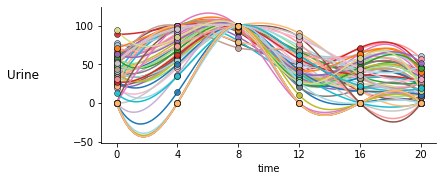

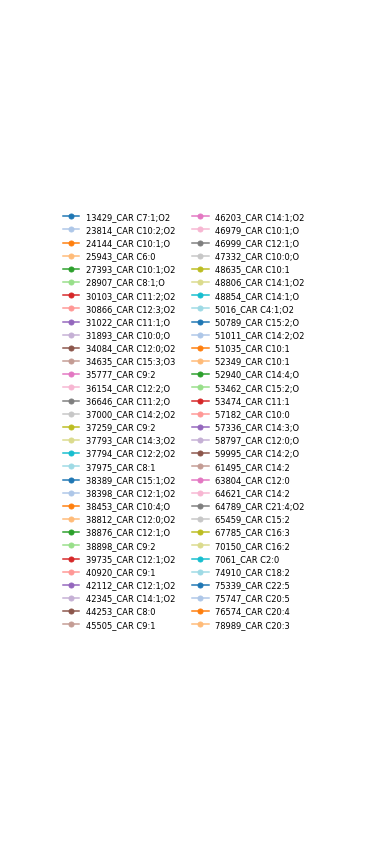

In [ ]:
fig = plot_timecourses_by_tissue(
    df,
    y_col="RelAbundance",
    show_ci=False,
    center="mean",
    ci_method="t",
    tissues=["Urine"],
    feature_group="Group2",
    show_points = False,
    show_center_points=True,
    return_legend_fig=True,
    # save_path='/.../lineplots/',               
    # legend_save_path='/.../lineplots/',
    export_pdf=True
)

In [ ]:
# then, repeat the same changinf tissue/biofluid and the group. 
# 9 of these plots are shown in the manuscript.
